In [1]:
packages <- c("ggplot2", "dplyr", "tidyr", "arrow", "RColorBrewer")
for (pkg in packages) {
    suppressMessages(
        suppressWarnings(
            library(pkg, character.only = TRUE)
    )   )
}

# every ggsave() call below writes into ../figures, which doesn't exist yet -
# create it once up front so ggsave() doesn't error out on the first plot.
dir.create("../figures", showWarnings = FALSE, recursive = TRUE)

In [2]:
# Get the current working directory and find Git root
find_git_root <- function() {
    # Get current working directory
    cwd <- getwd()
    
    # Check if current directory has .git
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    
    # If not, search parent directories
    current_path <- cwd
    while (dirname(current_path) != current_path) {  # While not at root
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    
    # If no Git root found, stop with error
    stop("No Git root directory found.")
}

# Find the Git root directory
root_dir <- find_git_root()
source(file.path(root_dir, "utils", "r_plot_themes.r"))

In [3]:
model_results_files = c(
    file.path(root_dir, "3.viability_prediction_models/model_results/combined_feature_importances.parquet"),
    file.path(root_dir, "3.viability_prediction_models/model_results/combined_predicted_viabilities.parquet"),
    file.path(root_dir, "3.viability_prediction_models/model_results/combined_summary_metrics.parquet")
)


In [4]:
feature_importances_df = arrow::read_parquet(
    file.path("../model_results/combined_feature_importances.parquet"))
# combined_summary_metrics.parquet only has the test-set mean/std/pooled
# aggregate (one Metadata_stat row per group, no Metadata_eval_split or
# Metadata_held_out_group column) - the per-fold plots below need the
# per-fold, per-eval-split rows instead, which live in
# combined_fold_metrics.parquet.
fold_metrics_df = arrow::read_parquet(file.path("../model_results/combined_fold_metrics.parquet"))

predicted_viabilities_df = arrow::read_parquet(
    file.path("../model_results/combined_predicted_viabilities.parquet"),
    col_select = c(
        Metadata_Biology_PatientTumor, Metadata_Experiment_Treatment,
        Metadata_Experiment_Dose, Metadata_Experiment_Class,
        Metadata_Experiment_Target, Metadata_Experiment_TherapeuticCategories,
        Metadata_fold, Metadata_held_out_group, Metadata_split_method,
        Metadata_shuffle_status, Metadata_profile_type, Metadata_source_file,
        Actual_Viability, Predicted_Viability
    )
)

In [5]:
# Keyword-based profile labeler for facet strips
label_profile_type <- function(profile_type) {
    #' Label a profile type based on keywords in the profile_type string.
    pt <- tolower(profile_type)

    dplyr::case_when(
        grepl("nucleocentric", pt) & grepl("chammi|morphem", pt) ~ "Nucleocentric MorphEM",
        grepl("nucleocentric", pt) & grepl("sammed", pt) ~ "Nucleocentric SAMMed3D",
        grepl("sammed", pt) ~ "SAMMed3D",
        grepl("morphem|chammi", pt) ~ "MorphEM",
        grepl("zedprofiler", pt) ~ "ZedProfiler",
        grepl("^organoid", pt) ~ "Organoid",
        grepl("^sc", pt) ~ "Single-cell",
        TRUE ~ gsub("_", " ", tools::toTitleCase(pt))
    )
}

# "norm_sc" in the profile_type name marks the profiles that were pooled
# across ALL patients and normalized a second time at that combined scale
# before consensus was computed (all_patients/0.normalized_profiles/
# sc_norm_norm_profile.parquet -> all_patients/3.consensus_profiles/
# ..._norm_sc_consensus_profiles.parquet), batch-correcting across patients.
# The plain "<level>_consensus_profiles" files instead have their consensus
# computed per patient, from that patient's own normalized data only
# (<patient>/7.aggregated_profiles -> <patient>/8.consensus_profiles). That's
# the actual difference between e.g. sc_consensus_profiles and
# sc_norm_sc_consensus_profiles (same distinction for the organoid-level
# pair) - label it explicitly so it's visible on every plot instead of
# being buried in the file name.
label_normalization_scope <- function(profile_type) {
    dplyr::case_when(
        grepl("norm_sc", profile_type, ignore.case = TRUE) ~ "Cross-patient normalized",
        TRUE ~ "Per-patient normalized"
    )
}

add_feature_type <- function(df) {
    #' Add columns classifying each profile by feature-extraction level
    #' (Metadata_feature_type) and by normalization scope
    #' (Metadata_normalization_scope - per-patient vs. cross-patient pooled),
    #' then combine both into a single facet-strip label
    #' (Metadata_profile_label) so the two consensus-profile variants per
    #' level are visually separated and annotated everywhere they're plotted.
    df %>%
        mutate(
            Metadata_feature_type = label_profile_type(Metadata_profile_type),
            Metadata_normalization_scope = label_normalization_scope(Metadata_profile_type),
            Metadata_profile_label = paste0(
                Metadata_feature_type, "\n(", Metadata_normalization_scope, ")"
            )
        )
}

fold_metrics_df          <- add_feature_type(fold_metrics_df)
feature_importances_df <- add_feature_type(feature_importances_df)
predicted_viabilities_df <- add_feature_type(predicted_viabilities_df)

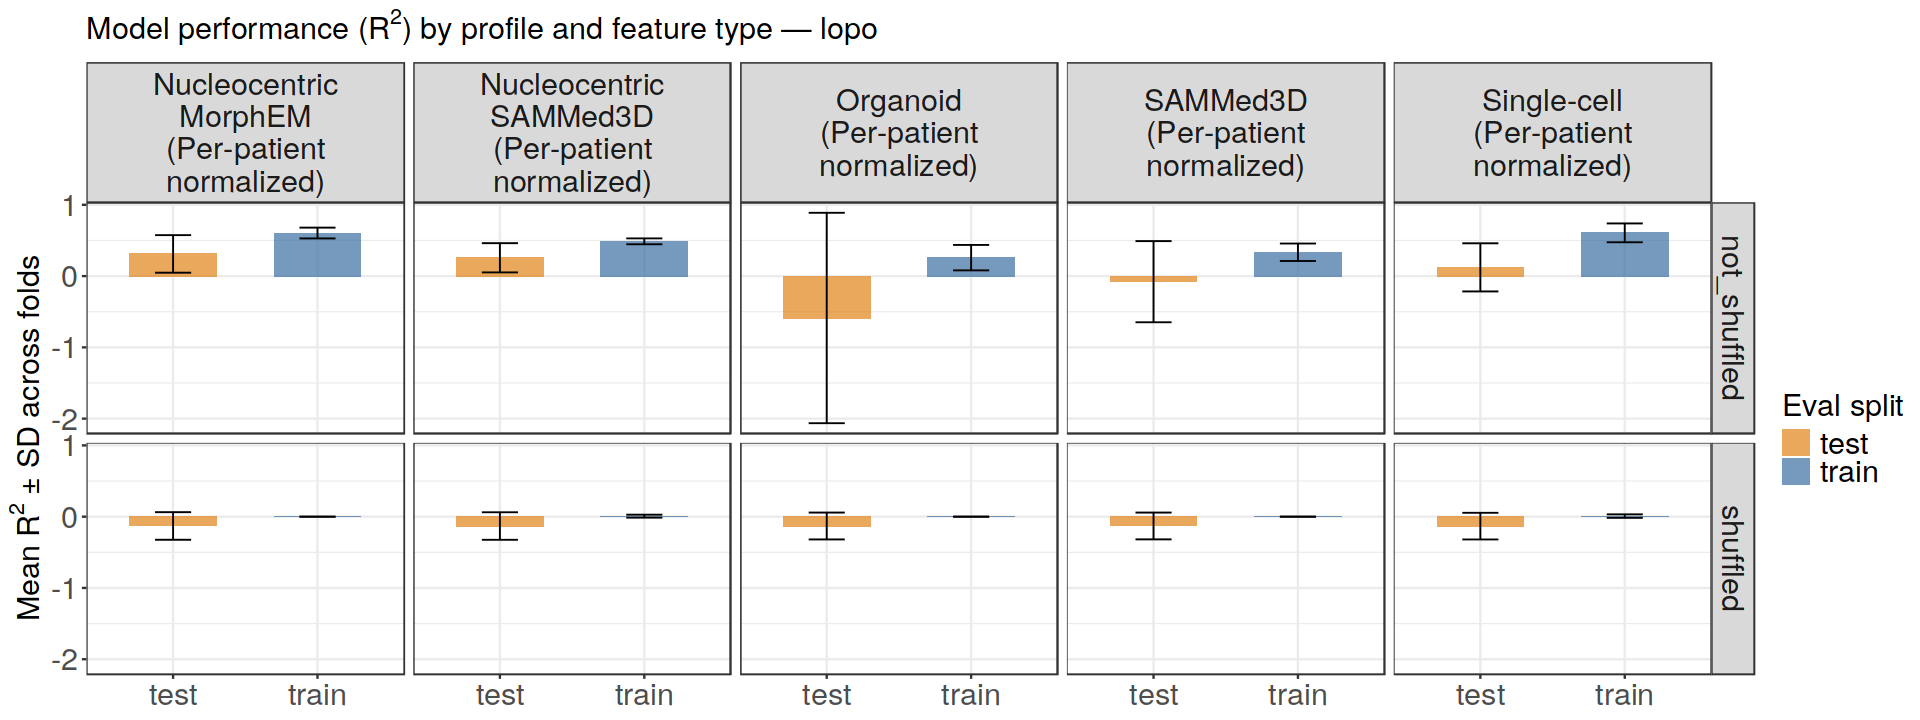

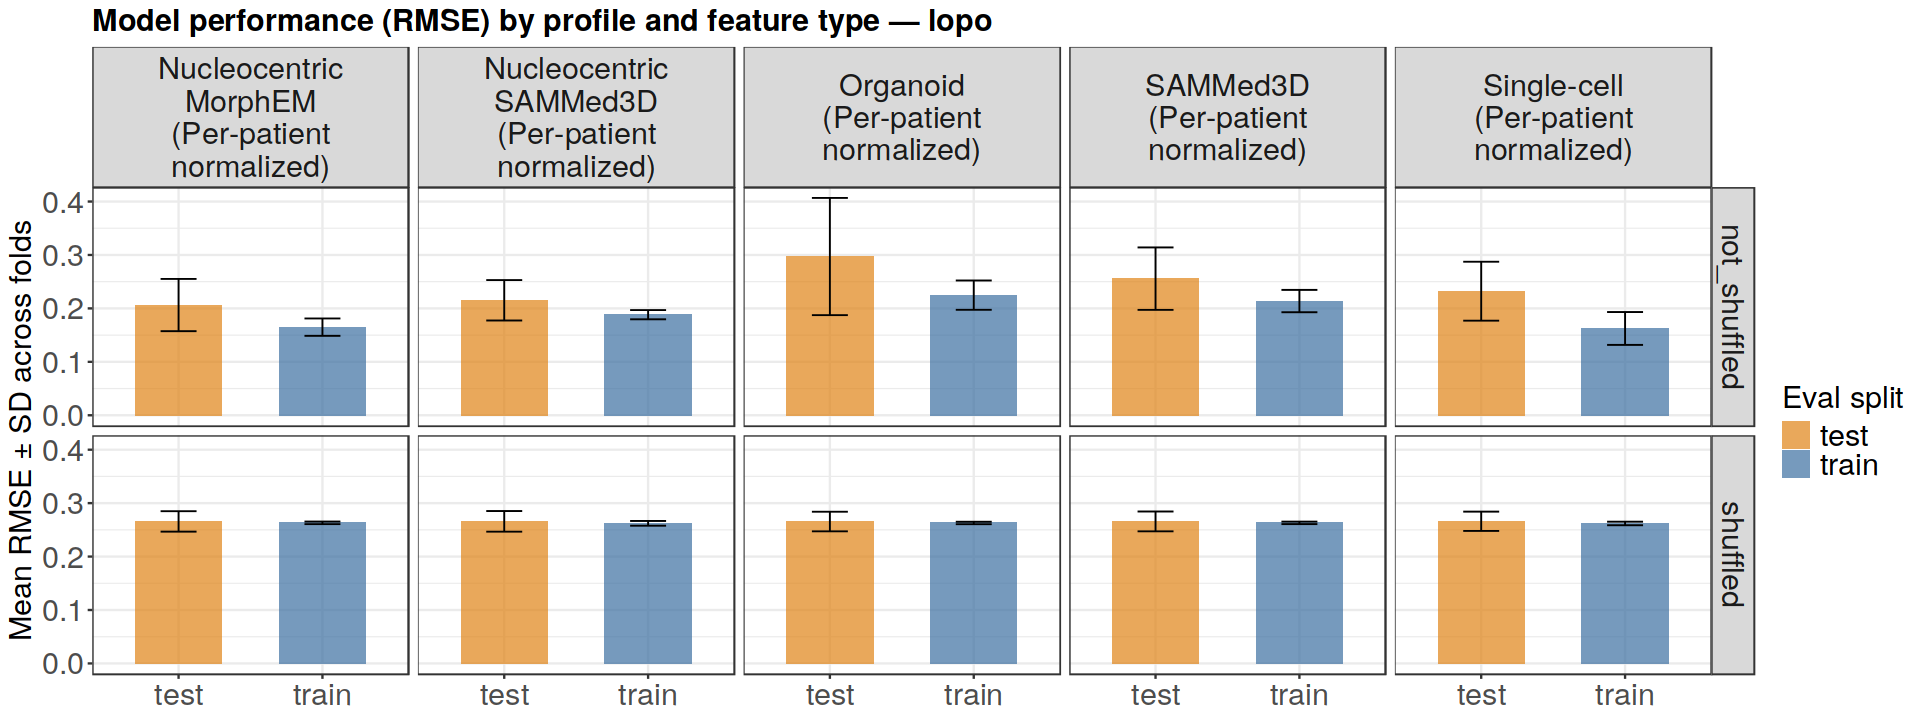

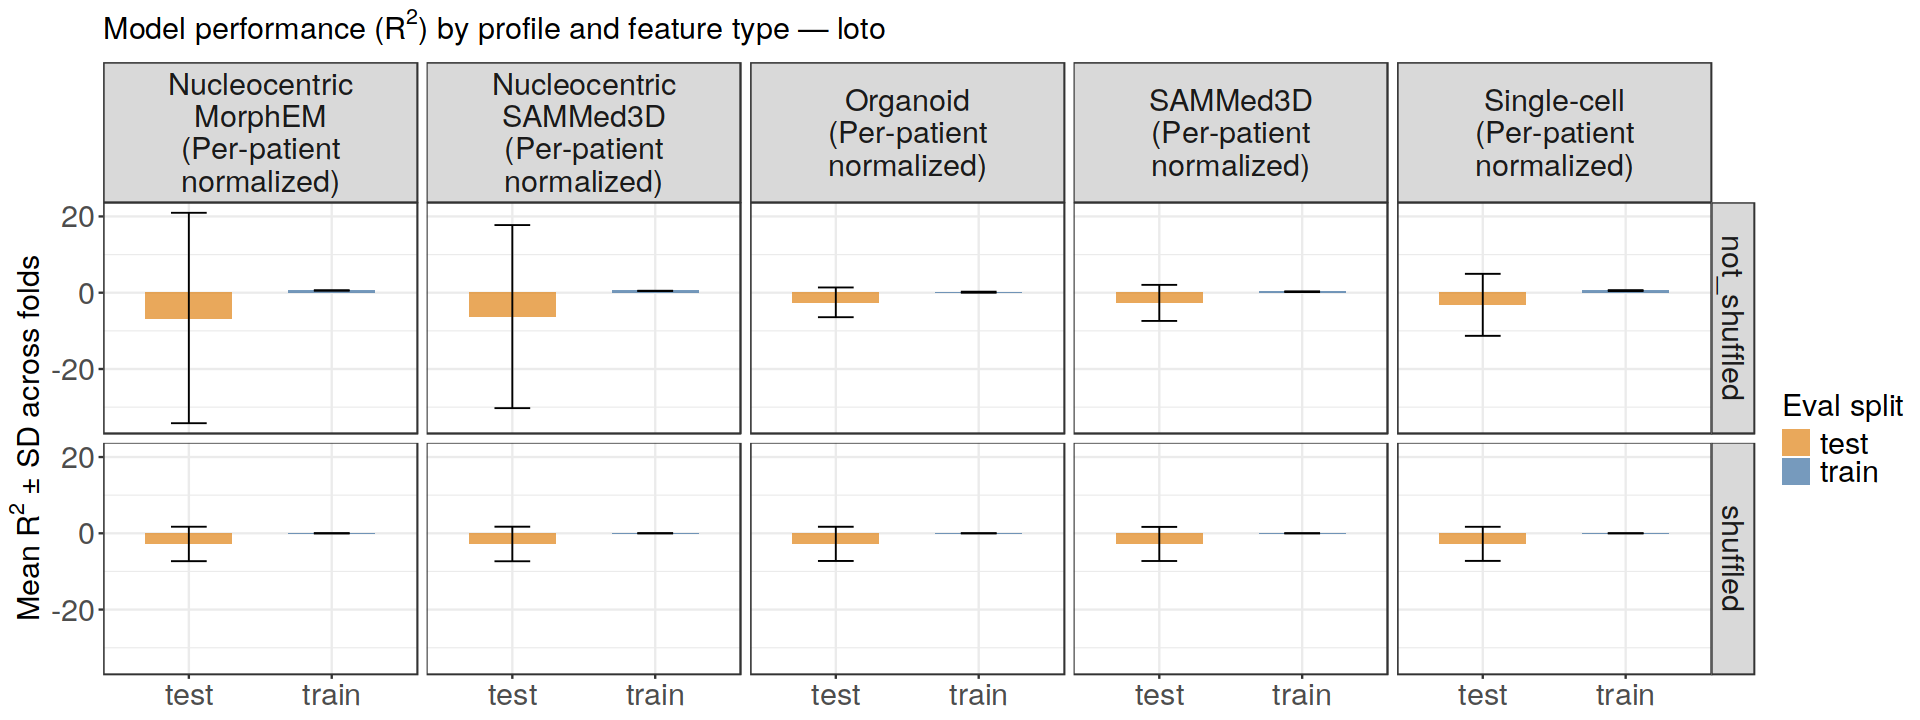

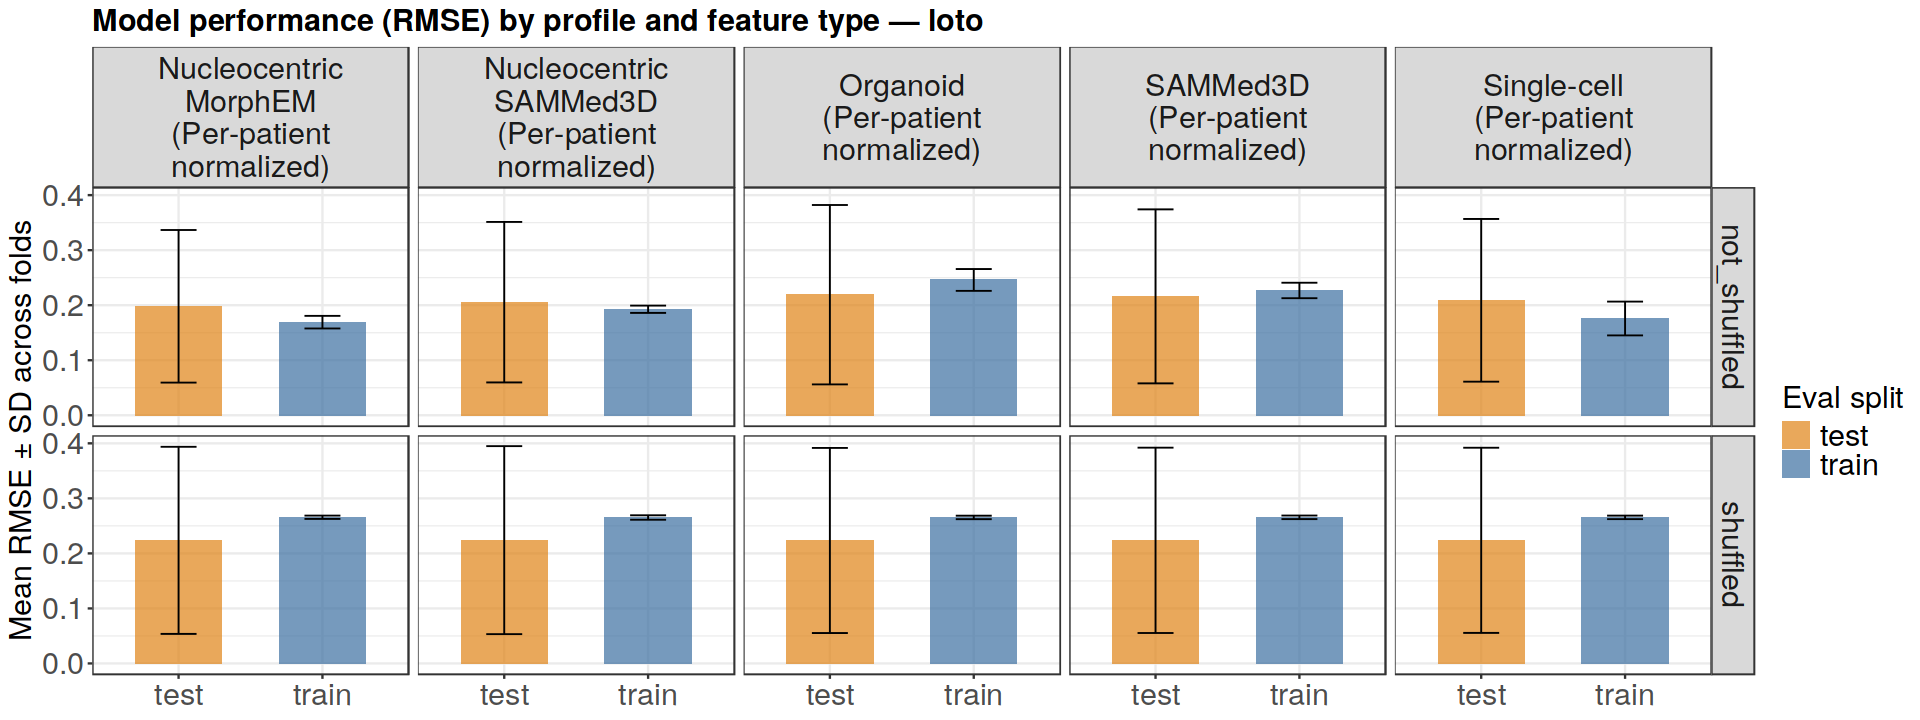

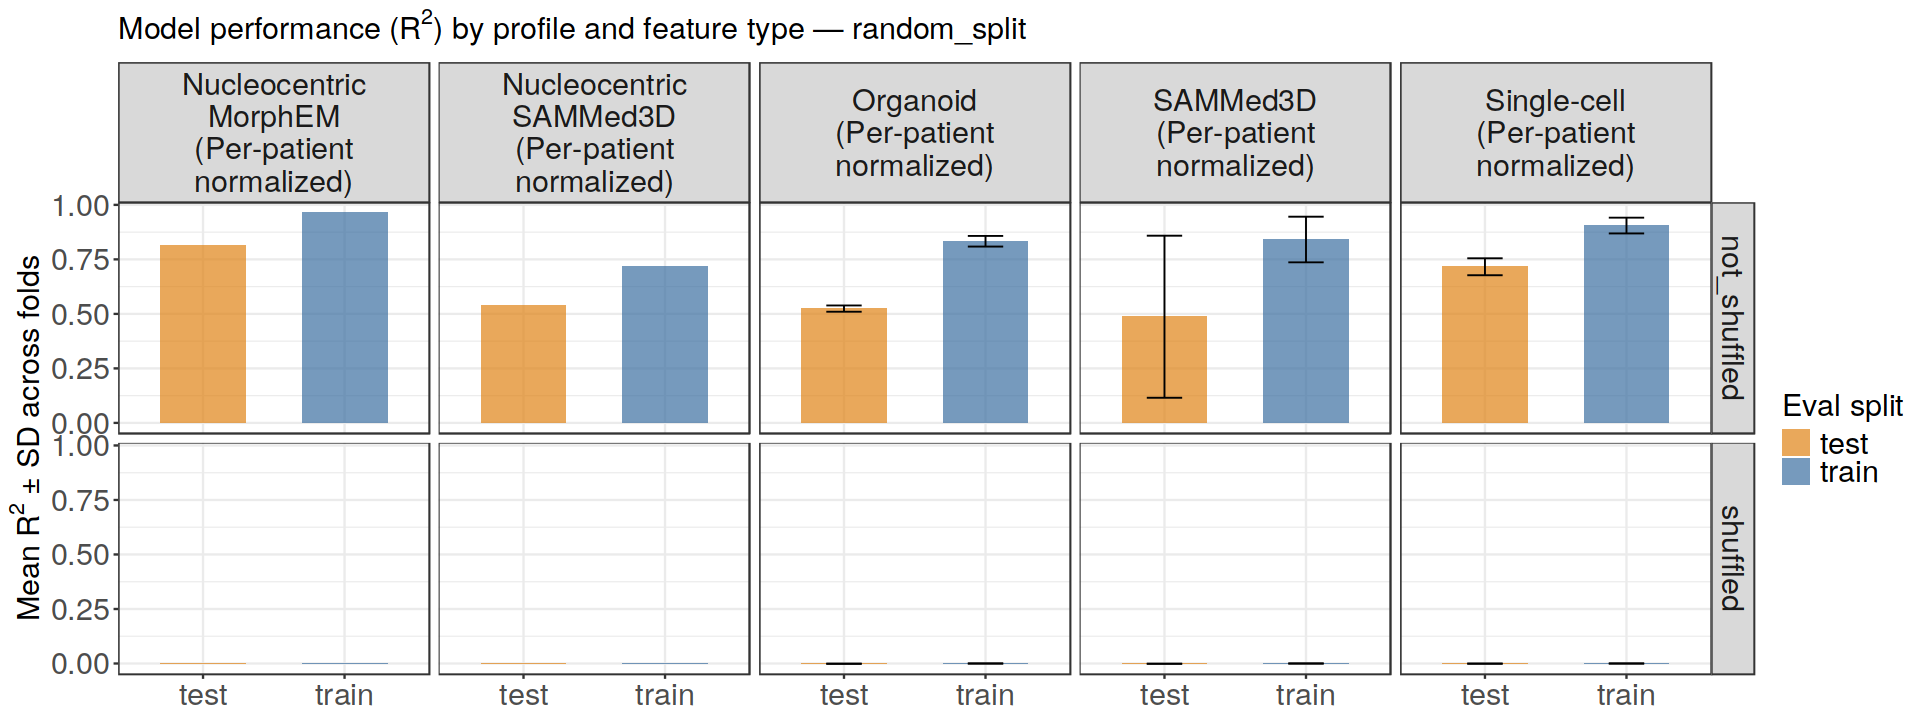

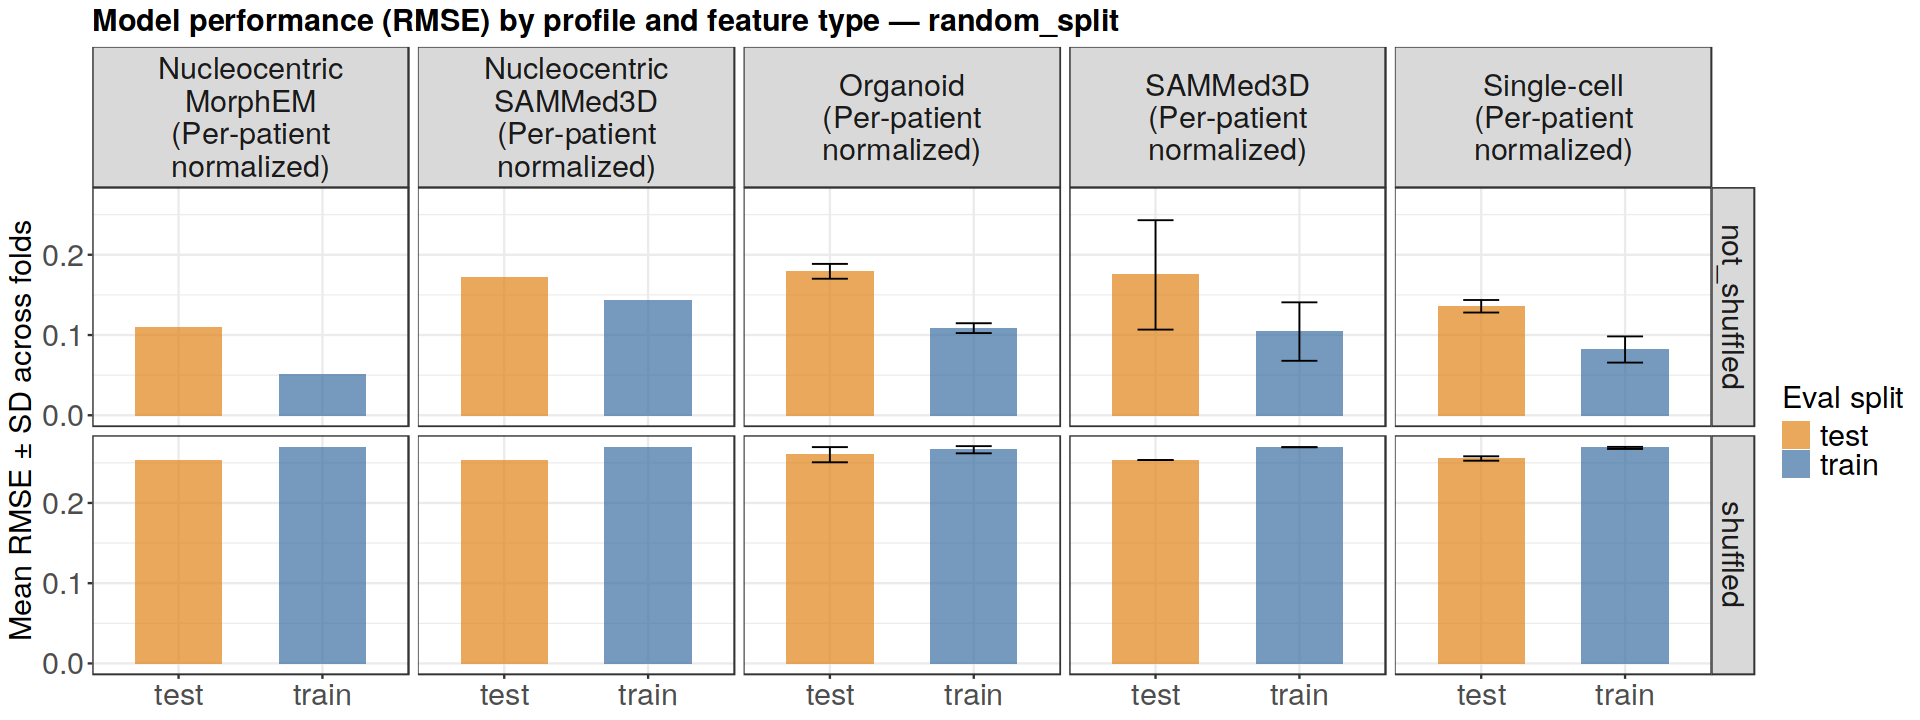

In [6]:
# ---------------------------------------------------------------------
# Per-fold model performance: R2 and RMSE by eval split, one plot per
# split method (mirroring the predicted-vs-actual plots below), faceted
# by shuffle status (rows) x profile - labeled with its feature type,
# handcrafted ZedProfiler vs. CHAMMI/SAMMed3D embedding (columns).
#
# Bars show the mean across folds per (eval_split, shuffle_status,
# profile) group, with error bars at +/- 1 SD - summarizing the same
# per-fold values the boxplots used to show individually.
#
# A handful of folds (mostly lopo/loto, tiny held-out groups) produce
# catastrophically bad fits - R2 down to ~-1e25, RMSE up to ~1e14. Those
# are real values (not a bug), but letting the scale include them
# flattens every other bar to a line. A fixed, clipped viewport
# (coord_cartesian, which zooms without recomputing the summary stats)
# keeps the bars readable; the caption reports how many folds fall
# outside the clipped view.
#
# Viability (and hence RMSE) is stored as a 0-1 fraction, not a 0-100
# percentage - RMSE_YLIM must be on that same scale or every real bar
# collapses to a line at 0 against outlier-driven clipping bounds.
# ---------------------------------------------------------------------
options(repr.plot.width = 16, repr.plot.height = 6)

eval_split_colors <- c(
    train = "#3B6FA0",
    test  = "#E08214"
)

R2_YLIM <- c(-1, 1)
RMSE_YLIM <- c(0, 1)

for (sm in unique(fold_metrics_df$Metadata_split_method)) {
    df_sub <- filter(fold_metrics_df, Metadata_split_method == sm)

    n_r2_clipped <- sum(df_sub$R2 < R2_YLIM[1], na.rm = TRUE)
    r2_summary_df <- df_sub %>%
        group_by(Metadata_eval_split, Metadata_shuffle_status, Metadata_profile_label) %>%
        summarise(mean_R2 = mean(R2), sd_R2 = sd(R2), n = n(), .groups = "drop")
    r2_plot <- (
        ggplot(r2_summary_df, aes(x = Metadata_eval_split, y = mean_R2, fill = Metadata_eval_split))
        + geom_col(alpha = 0.7, width = 0.6)
        + geom_errorbar(aes(ymin = mean_R2 - sd_R2, ymax = mean_R2 + sd_R2), width = 0.25, linewidth = 0.4)
        + facet_grid(
            Metadata_shuffle_status ~ Metadata_profile_label,
            labeller = labeller(Metadata_profile_label = label_wrap_gen(width = 18))
        )
        # + coord_cartesian(ylim = R2_YLIM)
        + scale_fill_manual(values = eval_split_colors, name = "Eval split")
        + labs(
            x = NULL,
            y = expression("Mean " * R^2 * " ± SD across folds"),
            title = bquote("Model performance (" * R^2 * ") by profile and feature type — " * .(sm)),
            # caption = paste0(
            #     "y-axis clipped to [", R2_YLIM[1], ", ", R2_YLIM[2], "]; ",
            #     n_r2_clipped, " of ", nrow(df_sub), " folds fall below this range."
            # )
        )
        + theme_manuscript()
    )
    ggsave(filename = file.path("../figures", paste0("r2_by_profile_", sm, ".png")), plot = r2_plot, width = 16, height = 6)
    print(r2_plot)

    n_rmse_clipped <- sum(df_sub$RMSE > RMSE_YLIM[2], na.rm = TRUE)
    rmse_summary_df <- df_sub %>%
        group_by(Metadata_eval_split, Metadata_shuffle_status, Metadata_profile_label) %>%
        summarise(mean_RMSE = mean(RMSE), sd_RMSE = sd(RMSE), n = n(), .groups = "drop")
    rmse_plot <- (
        ggplot(rmse_summary_df, aes(x = Metadata_eval_split, y = mean_RMSE, fill = Metadata_eval_split))
        + geom_col(alpha = 0.7, width = 0.6)
        + geom_errorbar(aes(ymin = mean_RMSE - sd_RMSE, ymax = mean_RMSE + sd_RMSE), width = 0.25, linewidth = 0.4)
        + facet_grid(
            Metadata_shuffle_status ~ Metadata_profile_label,
            labeller = labeller(Metadata_profile_label = label_wrap_gen(width = 18))
        )
        # + coord_cartesian(ylim = RMSE_YLIM)
        + scale_fill_manual(values = eval_split_colors, name = "Eval split")
        + labs(
            x = NULL, y = "Mean RMSE ± SD across folds",
            title = paste0("Model performance (RMSE) by profile and feature type — ", sm),
            # caption = paste0(
            #     "y-axis clipped to [", RMSE_YLIM[1], ", ", RMSE_YLIM[2], "]; ",
            #     n_rmse_clipped, " of ", nrow(df_sub), " folds exceed this range."
            # )
        )
        + theme_manuscript()
    )
    ggsave(filename = file.path("../figures", paste0("rmse_by_profile_", sm, ".png")), plot = rmse_plot, width = 16, height = 6)
    print(rmse_plot)
}

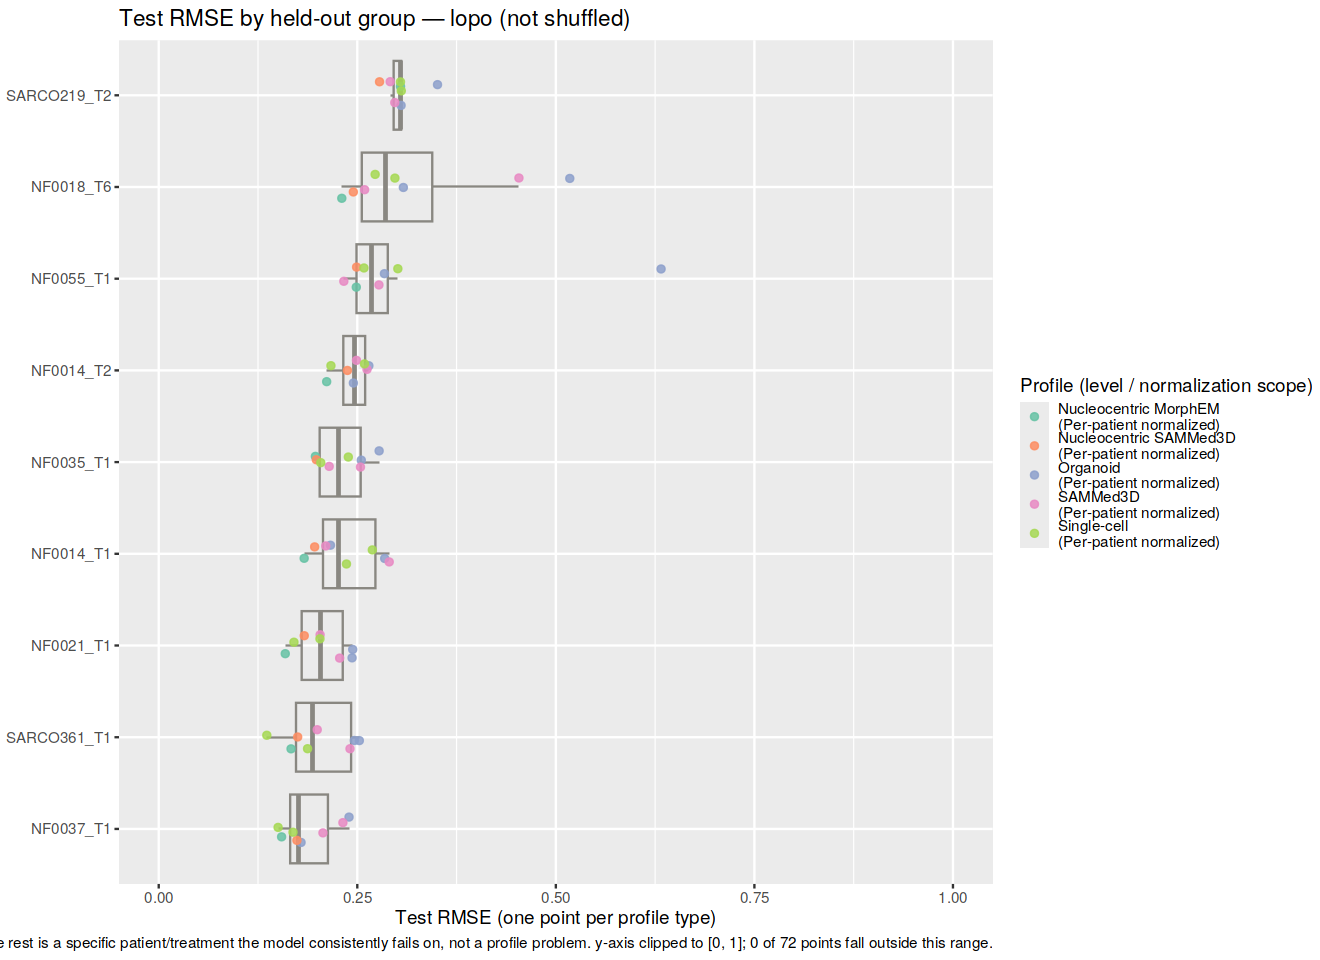

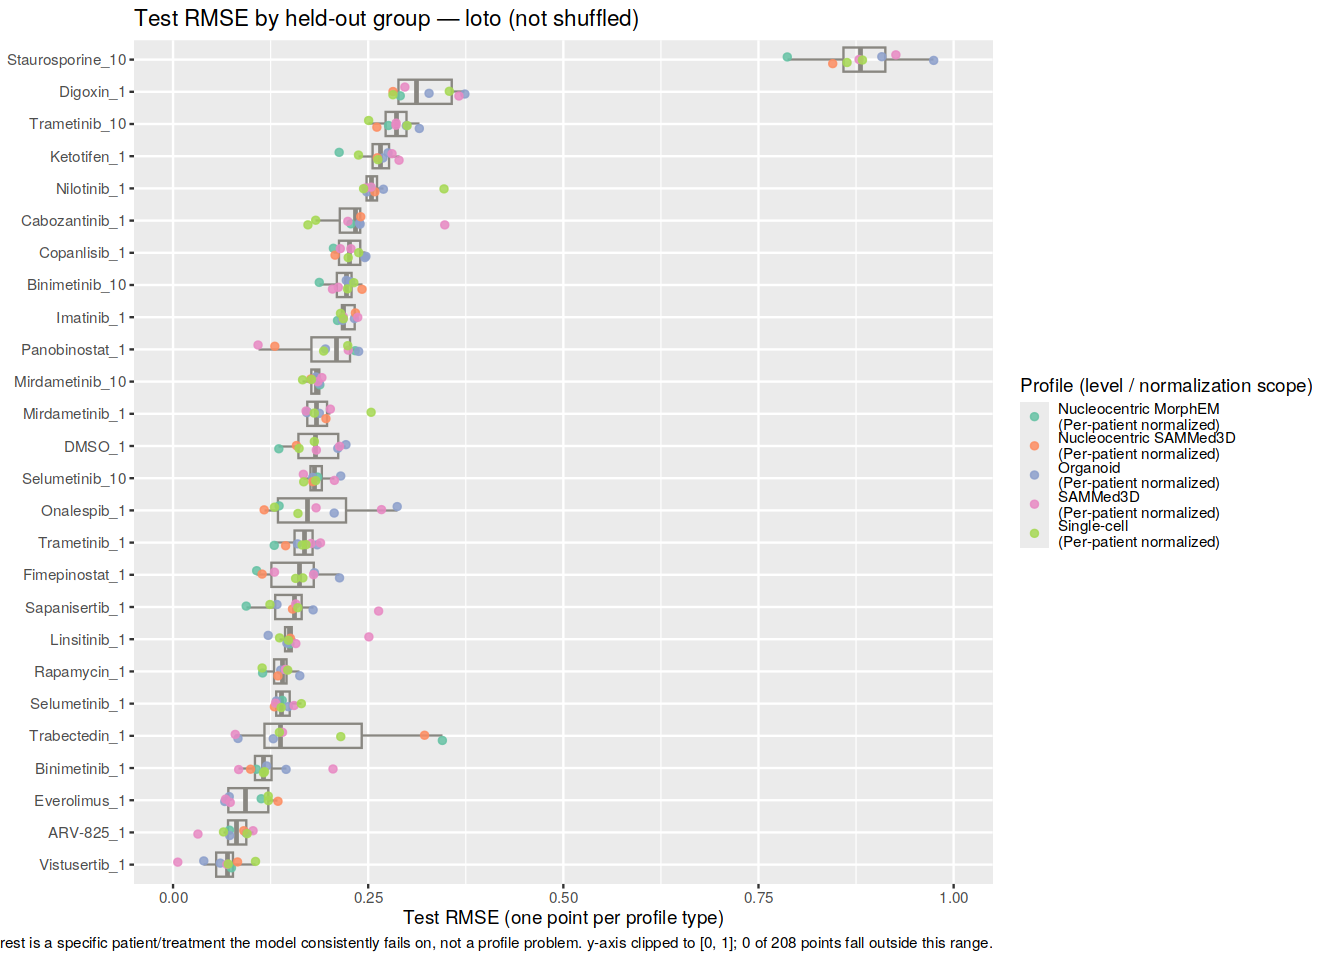

In [7]:
# ---------------------------------------------------------------------
# Per-held-out-group breakdown: is model failure spread evenly across
# patients/treatments, or concentrated in one or two of them?
#
# Every plot so far pools all folds into one number/box per profile, so
# a single catastrophic patient or treatment can drag an aggregate down
# without ever being visible on its own. fold_metrics_df already has one
# row per (fold, held_out_group, profile) - this just breaks it out by
# held_out_group instead of collapsing over it. random_split is
# excluded: its "held_out_group" is a single constant label (a random
# 30% holdout), not a biological group, so this breakdown isn't
# meaningful for it.
#
# Points are colored by the full profile label (level + normalization
# scope) so the per-patient vs. cross-patient-pooled variants of each
# level - the actual methodological split between e.g.
# sc_consensus_profiles and sc_norm_sc_consensus_profiles - are visibly
# distinct here too.
#
# RMSE is on the same 0-1 viability-fraction scale as everywhere else in
# this notebook, so the clip viewport must match.
# ---------------------------------------------------------------------
options(repr.plot.width = 11, repr.plot.height = 8)

GROUP_RMSE_YLIM <- c(0, 1)

for (sm in c("lopo", "loto")) {
    df_sub <- fold_metrics_df %>%
        filter(
            Metadata_split_method == sm,
            Metadata_eval_split == "test",
            Metadata_shuffle_status == "not_shuffled"
        )

    n_clipped <- sum(df_sub$RMSE > GROUP_RMSE_YLIM[2], na.rm = TRUE)

    group_plot <- (
        ggplot(
            df_sub,
            aes(x = reorder(Metadata_held_out_group, RMSE, FUN = median), y = RMSE)
        )
        + geom_boxplot(outlier.shape = NA, color = "#898781", fill = NA)
        + geom_jitter(aes(color = Metadata_profile_label), width = 0.15, height = 0, size = 1.6, alpha = 0.85)
        + coord_flip(ylim = GROUP_RMSE_YLIM)
        + scale_color_brewer(palette = "Set2", name = "Profile (level / normalization scope)")
        + labs(
            x = NULL, y = "Test RMSE (one point per profile type)",
            title = paste0("Test RMSE by held-out group — ", sm, " (not shuffled)"),
            caption = paste0(
                "Groups ordered by median RMSE across profiles; a group sitting far above the rest ",
                "is a specific patient/treatment the model consistently fails on, not a profile problem. ",
                "y-axis clipped to [", GROUP_RMSE_YLIM[1], ", ", GROUP_RMSE_YLIM[2], "]; ",
                n_clipped, " of ", nrow(df_sub), " points fall outside this range."
            )
        )
    )
    ggsave(filename = file.path("../figures", paste0("rmse_by_held_out_group_", sm, ".png")), plot = group_plot, width = 11, height = 8)
    print(group_plot)
}

In [8]:
# average each feature's coefficient across folds first (a single fold's
# coefficient is noisy), THEN rank by |mean coefficient| per profile type -
# ranking on per-fold values (as before) let one noisy fold's outlier
# coefficient dominate the "top features" list.
#
# Restrict to not_shuffled: shuffled-feature coefficients are a negative
# control (features are permuted, so their "importance" is noise by
# construction) and averaging them in would contaminate the real ranking.
#
# Average and rank WITHIN each split method (lopo/loto/random_split)
# too, not just within each profile type - lopo, loto, and random_split
# are trained on different fold structures (different held-out groups,
# different fold counts: 7 vs ~26 vs 1), so they are effectively
# different models and can legitimately settle on different top
# features. Pooling their coefficients together (as before) let the
# ~26-fold loto model's coefficients dominate the 7-fold lopo model's.
feature_importance_avg_df <- feature_importances_df %>%
    filter(Metadata_shuffle_status == "not_shuffled") %>%
    group_by(Metadata_profile_type, Metadata_split_method, feature) %>%
    summarise(mean_importance = mean(importance), .groups = "drop") %>%
    mutate(
        abs_importance = abs(mean_importance),
        Metadata_profile_label = paste0(
            label_profile_type(Metadata_profile_type), "\n(", label_normalization_scope(Metadata_profile_type), ")"
        )
    )

top_features_df <- feature_importance_avg_df %>%
    group_by(Metadata_profile_type, Metadata_split_method) %>%
    slice_max(order_by = abs_importance, n = 10, with_ties = FALSE) %>%
    ungroup()

head(top_features_df)

Metadata_profile_type,Metadata_split_method,feature,mean_importance,abs_importance,Metadata_profile_label
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
nucleocentric_morphem_profile_consensus,lopo,Nucleocentric_DNA_CHAMMI75_Feature264,0.044386065,0.044386065,Nucleocentric MorphEM (Per-patient normalized)
nucleocentric_morphem_profile_consensus,lopo,Nucleocentric_DNA_CHAMMI75_Feature199,0.019980918,0.019980918,Nucleocentric MorphEM (Per-patient normalized)
nucleocentric_morphem_profile_consensus,lopo,Nucleocentric_DNA_CHAMMI75_Feature15,0.019577697,0.019577697,Nucleocentric MorphEM (Per-patient normalized)
nucleocentric_morphem_profile_consensus,lopo,Nucleocentric_DNA_CHAMMI75_Feature84,0.012869965,0.012869965,Nucleocentric MorphEM (Per-patient normalized)
nucleocentric_morphem_profile_consensus,lopo,Nucleocentric_DNA_CHAMMI75_Feature184,-0.011982061,0.011982061,Nucleocentric MorphEM (Per-patient normalized)
nucleocentric_morphem_profile_consensus,lopo,Nucleocentric_AGP_CHAMMI75_Feature4,-0.007994951,0.007994951,Nucleocentric MorphEM (Per-patient normalized)


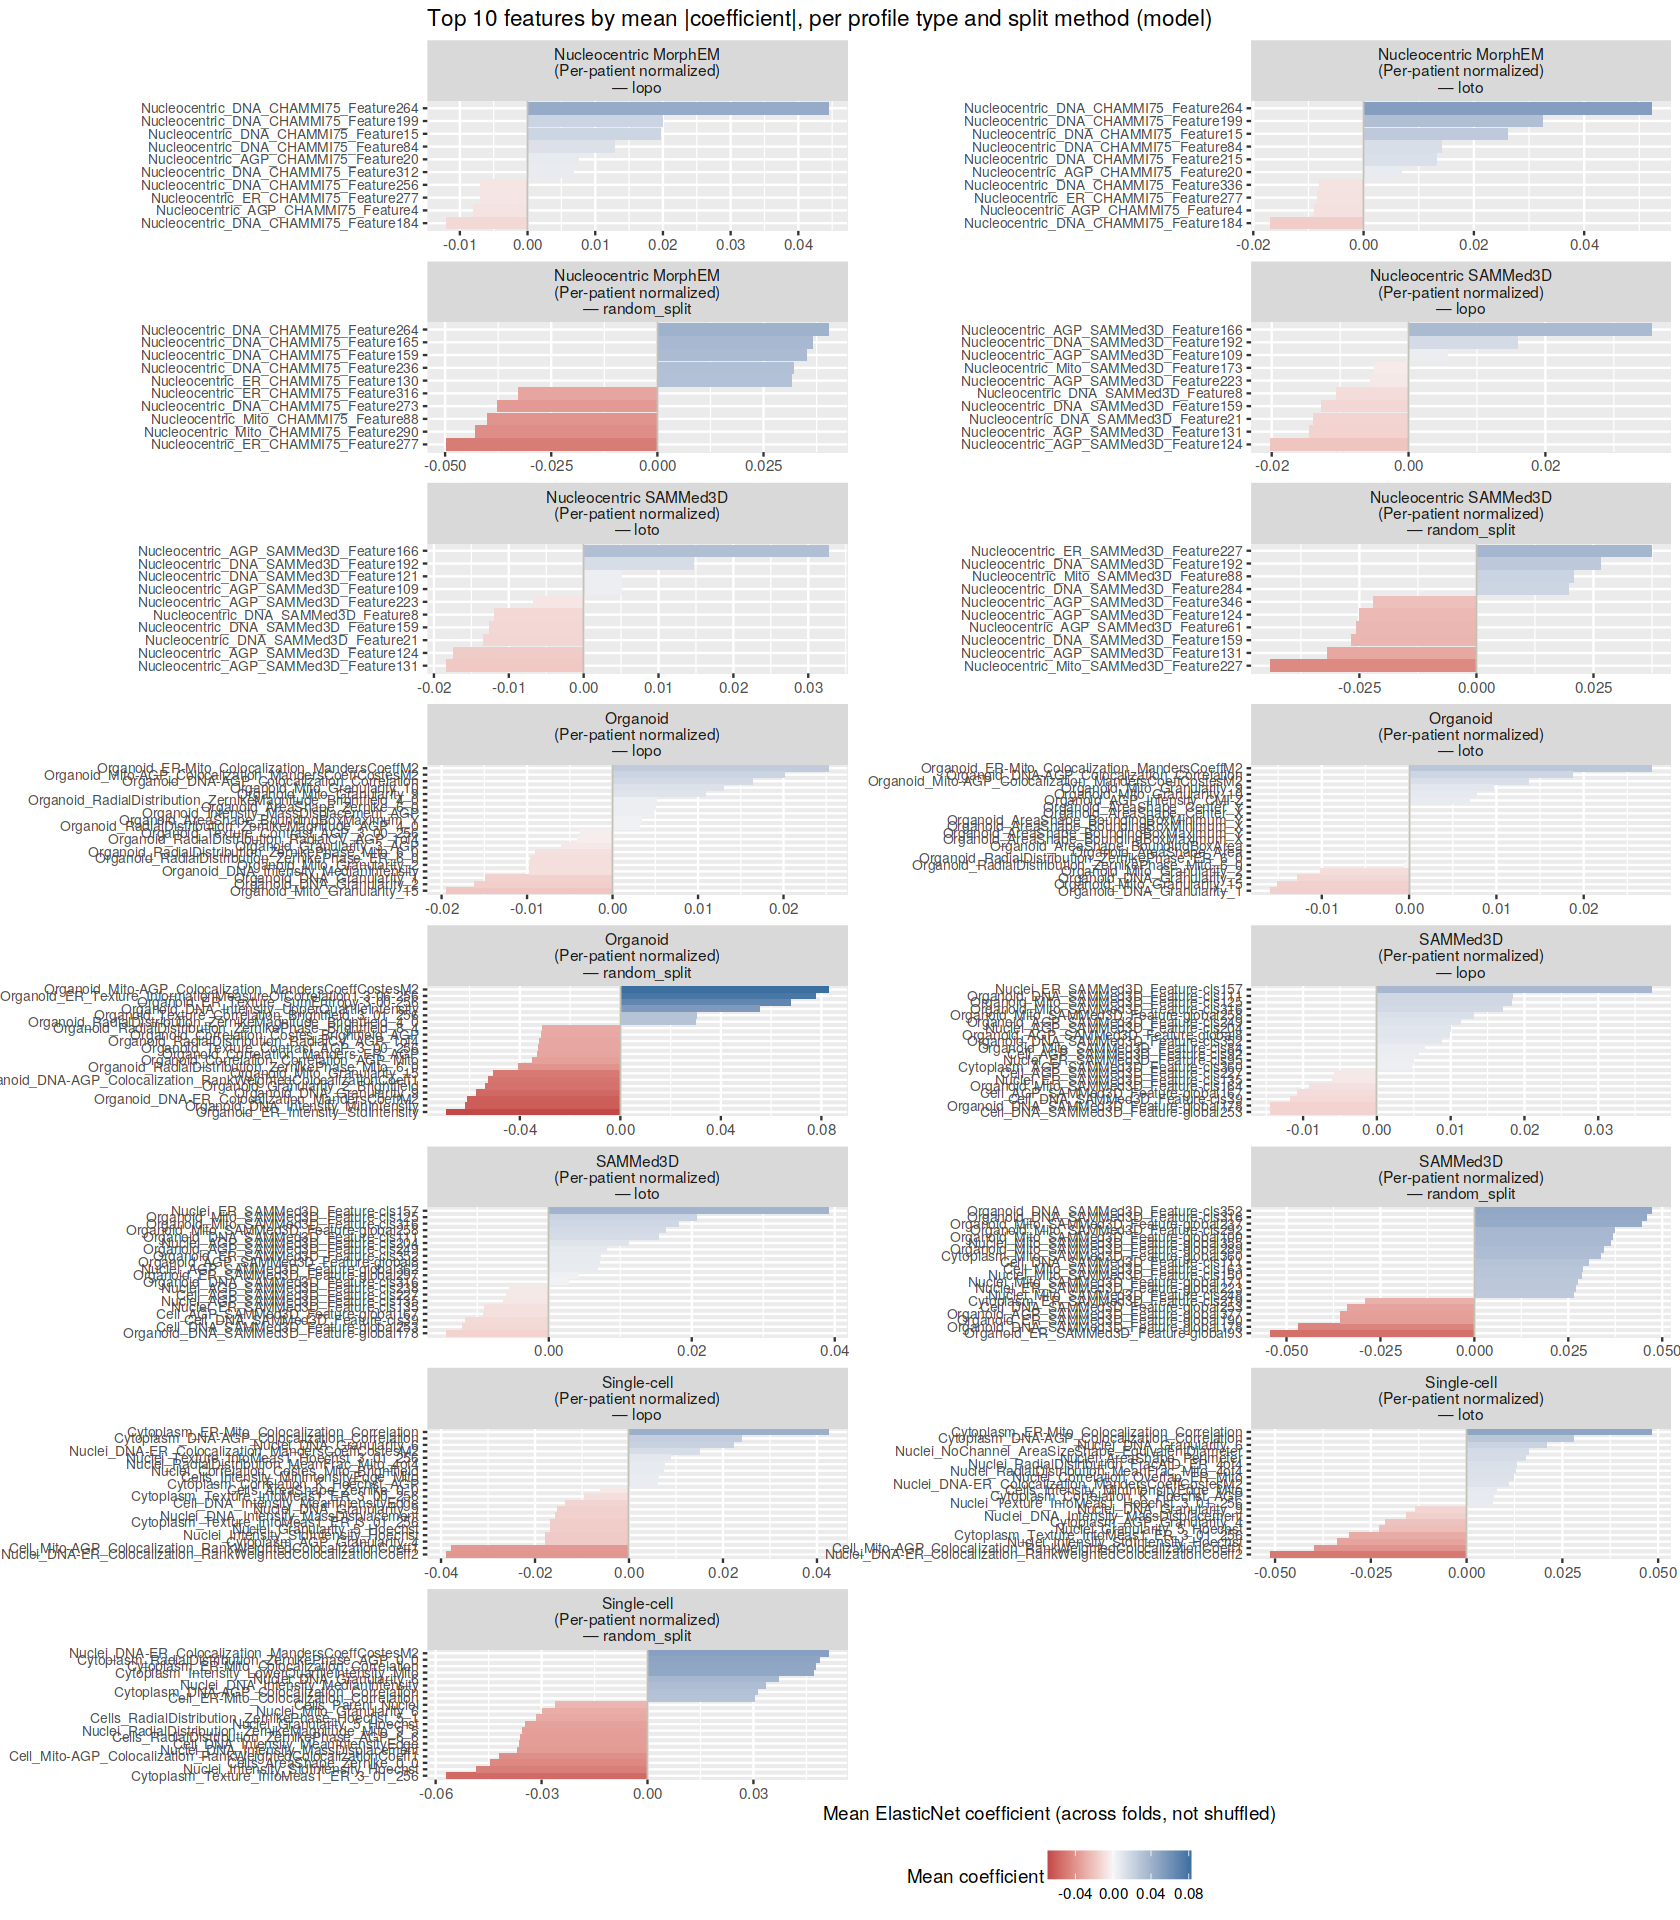

In [9]:
height <- 16
width <- 14
options(repr.plot.width = width, repr.plot.height = height)

# Each (profile_type, split_method) panel ranks its own top 10 features, so
# the feature names on the y-axis are completely different from one panel
# to the next - facet_grid forces every panel in a row/column to share one
# axis, which doesn't make sense here. facet_wrap(scales = "free") gives
# each panel its own axes, but reorder() alone still produces one shared
# factor level order across all panels (ggplot's classic
# "same category, different order per facet" trap - a feature that ranks
# #1 in one panel and is absent from another would otherwise pull every
# panel onto the same combined level order). reorder_within/
# scale_x_reordered (the tidytext trick, reimplemented here directly since
# tidytext isn't installed) works around this by disambiguating each
# feature's factor level with its facet label before reordering, then
# stripping that suffix back off for display.
reorder_within <- function(x, by, within, sep = "___") {
    new_x <- paste(x, within, sep = sep)
    stats::reorder(new_x, by)
}
scale_x_reordered <- function(..., sep = "___") {
    ggplot2::scale_x_discrete(labels = function(x) gsub(paste0(sep, ".+$"), "", x), ...)
}

top_features_df <- top_features_df %>%
    mutate(
        Metadata_facet_label = paste0(Metadata_profile_label, "\n— ", Metadata_split_method)
    )

# feature coefficients are a polarity, not a category or a magnitude alone -
# a diverging scale (not a categorical fill) is the correct encoding for
# "which direction did this feature push the prediction".
feature_importances_plot <- (
    ggplot(
        top_features_df,
        aes(x = reorder_within(feature, mean_importance, Metadata_facet_label), y = mean_importance, fill = mean_importance)
    )
    + geom_col()
    + geom_hline(yintercept = 0, color = "#c3c2b7", linewidth = 0.4)
    + scale_x_reordered()
    + facet_wrap(~Metadata_facet_label, scales = "free", ncol = 2)
    + coord_flip()
    + scale_fill_gradient2(
        low = "#B2182B",
        mid = "#F7F7F7",
        high = "#3B6FA0",
        midpoint = 0,
        name = "Mean coefficient"
    )
    + labs(
        x = NULL,
        y = "Mean ElasticNet coefficient (across folds, not shuffled)",
        title = "Top 10 features by mean |coefficient|, per profile type and split method (model)"
    )
    + theme(legend.position = "none")
    + theme(
        axis.text.y = element_text(size = 8),
        strip.text = element_text(size = 9),
        legend.position = "bottom"
    )
)
ggsave(filename = file.path("../figures", "top_feature_importances_by_profile.png"), plot = feature_importances_plot, width = width, height = height)
feature_importances_plot

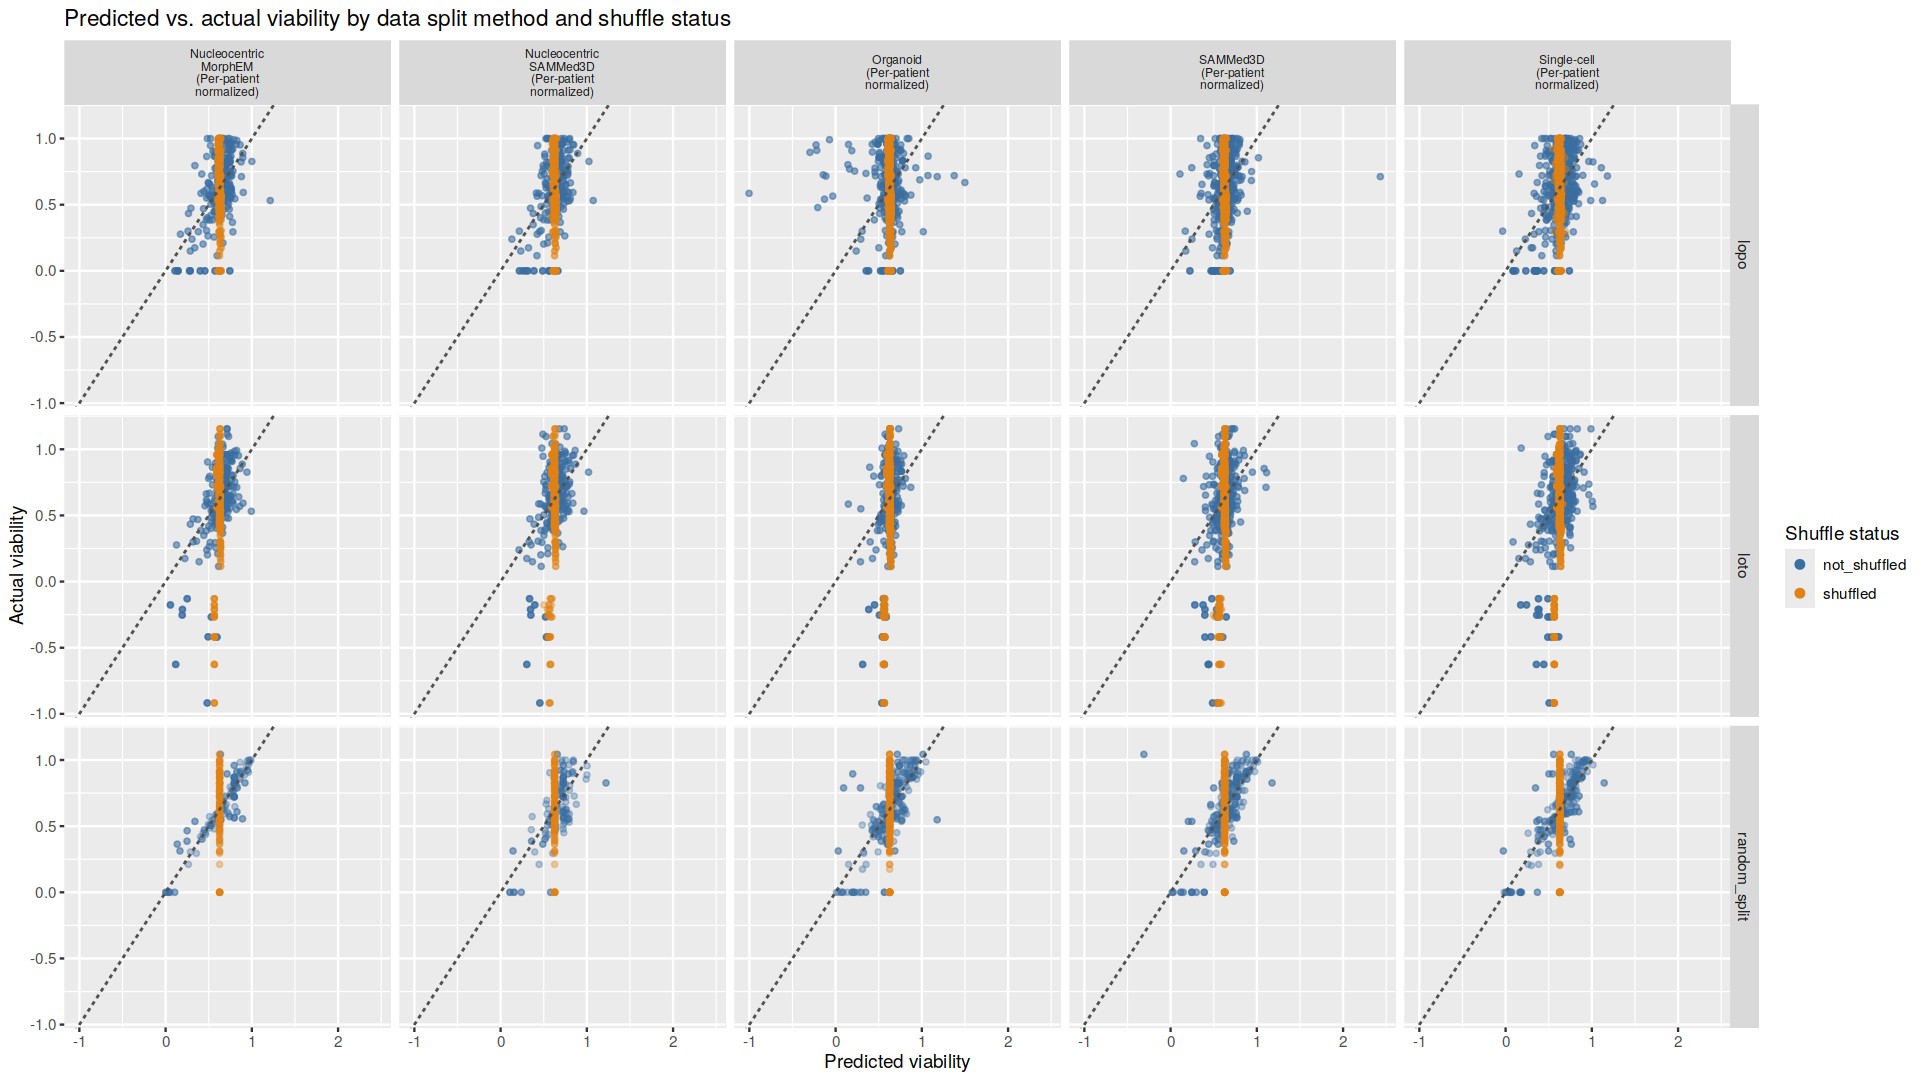

In [10]:
# predicted vs actual viability, one combined plot faceted by data split
# method (rows) x profile - labeled with its feature type (columns), with
# points colored by shuffle status so the not_shuffled fits and their
# shuffled-feature negative control sit in the same panel for direct
# comparison instead of separate figures.
options(repr.plot.width = 16, repr.plot.height = 9)

shuffle_status_colors <- c(
    not_shuffled = "#3B6FA0",
    shuffled      = "#E08214"
)

pred_vs_actual_plot <- (
    ggplot(
        predicted_viabilities_df,
        aes(x = Predicted_Viability, y = Actual_Viability, color = Metadata_shuffle_status)
    )
    + geom_point(alpha = 0.35, size = 1.1)
    + geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "#52514e", linewidth = 0.6)
    + facet_grid(
        Metadata_split_method ~ Metadata_profile_label,
        labeller = labeller(Metadata_profile_label = label_wrap_gen(width = 18))
    )
    + scale_color_manual(values = shuffle_status_colors, name = "Shuffle status")
    + guides(color = guide_legend(override.aes = list(alpha = 1, size = 2)))
    + labs(
        x = "Predicted viability", y = "Actual viability",
        title = "Predicted vs. actual viability by data split method and shuffle status",
    )
    + theme(strip.text.x = element_text(size = 7), strip.text.y = element_text(size = 9))
)
ggsave(filename = file.path("../figures", "predicted_vs_actual.png"), plot = pred_vs_actual_plot, width = 16, height = 9)
pred_vs_actual_plot

In [ ]:
# investigate the top features for each of the models by plotting the distributions of the feature for each model type
#
# A ranked |coefficient| alone doesn't say much about a feature - a
# tiny coefficient on a feature with huge variance can matter as much
# as a large coefficient on a near-constant one, and a coefficient
# can't show whether the feature is normally spread, skewed, or driven
# by a handful of outlier wells. This pulls each model's own top-10
# features (same list as the importance plot above) back out of the
# raw, normalized consensus profiles and plots their actual value
# distributions across all wells - one panel per model, mirroring the
# facet layout above so the two plots read side by side.
#
# The raw profiles aren't loaded anywhere else in this notebook (only
# their downstream importances/performance/predictions are) - read
# them directly from 3.viability_prediction_models/data/processed_profiles_3D,
# the exact files the models in top_features_df were trained on (see
# 1.viability_prediction.ipynb's consensus_profiles_3D_paths / feature_cols).
# Those files are keyed by Metadata_profile_type value, not by filename -
# "organoid_profile_consensus" / "sc_profile_consensus" are the literal
# Metadata_profile_type strings the 3D lopo/loto/random_split models were
# trained under (all_patients/3.consensus_profiles/*_norm_sc_consensus_profiles.parquet
# is a different, unrelated consensus pipeline the models never saw - using
# it here left this join empty for every row, which is why the facet below
# used to fail with "Faceting variables must have at least one value").
# Only pivot the handful of columns actually needed per profile type rather
# than all 837-2241 feature columns.
options(repr.plot.width = width, repr.plot.height = height)

raw_profile_paths <- c(
    organoid_profile_consensus = file.path(root_dir, "3.viability_prediction_models/data/processed_profiles_3D/organoid_profile_consensus.parquet"),
    sc_profile_consensus       = file.path(root_dir, "3.viability_prediction_models/data/processed_profiles_3D/sc_profile_consensus.parquet")
)

top_feature_names <- unique(top_features_df$feature)

feature_values_list <- list()
for (pt in names(raw_profile_paths)) {
    raw_df <- arrow::read_parquet(raw_profile_paths[[pt]])
    keep_cols <- intersect(top_feature_names, colnames(raw_df))
    feature_values_list[[pt]] <- raw_df %>%
        select(all_of(keep_cols)) %>%
        mutate(Metadata_profile_type = pt) %>%
        pivot_longer(cols = all_of(keep_cols), names_to = "feature", values_to = "value")
}
feature_values_df <- bind_rows(feature_values_list)

# many-to-many: the same (profile_type, feature) raw values are pulled
# in once per split method that ranked it into its own top 10, so a
# feature shared across lopo/loto/random_split's top-10 lists correctly
# gets its own panel under each of them.
feature_dist_df <- feature_values_df %>%
    inner_join(
        top_features_df %>% select(Metadata_profile_type, Metadata_split_method, feature, mean_importance, Metadata_facet_label),
        by = c("Metadata_profile_type", "feature"),
        relationship = "many-to-many"
    )

# Cross-patient normalization produces the same degenerate near-zero-
# variance -> huge-z-score artifact documented elsewhere in this
# notebook (predicted viabilities up to ~1e13): a handful of wells sit
# at ~1e18-1e19 on an otherwise unit-scale feature. A single feature's
# panel-mate can still be at the ~99.7th percentile of its OWN
# distribution, so a flat 1st-99th percentile clip isn't tight enough -
# each panel shares one free x-axis across its 10 features, so one
# under-clipped feature still stretches the whole panel. Use the
# standard Tukey boxplot fence instead (median's IQR x 1.5 beyond
# Q1/Q3) per (facet, feature) group, which is exactly the same
# "outlier" definition geom_boxplot itself uses, so what's clipped
# here matches what geom_boxplot would flag as an outlier point.
feature_dist_df <- feature_dist_df %>%
    group_by(Metadata_facet_label, feature) %>%
    mutate(
        q1 = quantile(value, 0.25, na.rm = TRUE),
        q3 = quantile(value, 0.75, na.rm = TRUE),
        iqr = q3 - q1,
        fence_low = q1 - 1.5 * iqr,
        fence_high = q3 + 1.5 * iqr,
        value_clipped = pmin(pmax(value, fence_low), fence_high)
    ) %>%
    ungroup()

n_dist_clipped <- sum(feature_dist_df$value != feature_dist_df$value_clipped, na.rm = TRUE)

feature_dist_plot <- (
    ggplot(
        feature_dist_df,
        aes(x = reorder_within(feature, mean_importance, Metadata_facet_label), y = value_clipped, fill = mean_importance)
    )
    + geom_violin(alpha = 0.6, linewidth = 0.3, scale = "width")
    + geom_boxplot(width = 0.12, outlier.size = 0.5, alpha = 0.9, fill = "white")
    + scale_x_reordered()
    + facet_wrap(~Metadata_facet_label, scales = "free", ncol = 2)
    + coord_flip()
    + scale_fill_gradient2(
        low = "#B2182B",
        mid = "#F7F7F7",
        high = "#3B6FA0",
        midpoint = 0,
        name = "Mean coefficient\n(from importance plot)"
    )
    + labs(
        x = NULL,
        y = "Feature value (normalized consensus profile, all wells)",
        title = "Distribution of each model's top-10 features across all profiles",
        caption = paste0(
            "Each (panel, feature) clipped to its own Tukey fence (median IQR x 1.5 beyond Q1/Q3); ",
            n_dist_clipped, " of ", nrow(feature_dist_df), " points were pulled in by this - ",
            "the same cross-patient-normalization outlier artifact documented elsewhere in this notebook."
        )
    )
    + theme(
        axis.text.y = element_text(size = 8),
        strip.text = element_text(size = 9),
        legend.position = "bottom"
    )
)
ggsave(filename = file.path("../figures", "top_feature_distributions_by_profile.png"), plot = feature_dist_plot, width = width, height = height)
feature_dist_plot

In [ ]:
# ---------------------------------------------------------------------
# The plot above shows each model's top-10 features are spread out with
# a long tail of Tukey-fence "edge" values (already computed as
# fence_low/fence_high in feature_dist_df) - but that plot works on
# CONSENSUS profiles, one row per (patient, treatment, dose) condition,
# not per physical specimen. To actually go find and re-inspect the
# organoids/cells behind those edge values under the microscope, we
# need the pre-aggregation, per-object profiles - each row there is one
# real organoid or cell with its own segmentation centroid.
#
# organoid_flagged_outliers.parquet / sc_flagged_outliers.parquet (per
# patient, in 4.qc_profiles/) are the earliest per-object tables that
# still carry both the raw feature values and the
# Metadata_Location_<compartment>_{Center,Min,Max}{X,Y,Z} columns -
# everything downstream of QC aggregates them away. Pulling the min/max
# bounding box in here too (not just the center) means every downstream
# table - edge_objects_df, extreme_objects_df - already carries what's
# needed to crop the raw image directly, instead of having to re-read
# this same QC parquet a second time later just for the bbox. Read only
# the patient directories (not all_patients/, which is
# already-aggregated) and only the top-10 feature columns actually
# needed, across all 13 patient/tumor folders.
patient_dirs <- setdiff(
    list.dirs(file.path(root_dir, "data", "profiles_3D"), recursive = FALSE, full.names = FALSE),
    "all_patients"
)

read_object_features <- function(filename, compartments) {
    #' Read one QC-object-level parquet per patient, keep only the top-10
    #' feature columns plus identifying/location metadata, and stack
    #' every patient into one long (feature, value) table with the
    #' correct compartment-specific center AND bounding box attached to
    #' each row.
    location_cols <- as.vector(outer(
        paste0("Metadata_Location_", compartments),
        c("CenterX", "CenterY", "CenterZ", "MinX", "MinY", "MinZ", "MaxX", "MaxY", "MaxZ"),
        paste, sep = "_"
    ))

    object_list <- list()
    for (patient in patient_dirs) {
        path <- file.path(root_dir, "data", "profiles_3D", patient, "4.qc_profiles", filename)
        if (!file.exists(path)) next
        raw_df <- arrow::read_parquet(path)
        keep_feat_cols <- intersect(top_feature_names, colnames(raw_df))
        if (length(keep_feat_cols) == 0) next
        keep_location_cols <- intersect(location_cols, colnames(raw_df))
        object_list[[patient]] <- raw_df %>%
            # ObjectID 0 is CellProfiler's per-FOV background/empty-mask
            # placeholder row (all-zero features, no real centroid) - not
            # a physical specimen, and it was showing up as a bogus
            # "extreme low" value below (value exactly 0, center NA) if
            # left in.
            filter(Metadata_Object_ObjectID != 0) %>%
            select(
                Metadata_Biology_PatientTumor, Metadata_Experiment_Well, Metadata_Experiment_WellFOV,
                Metadata_Experiment_Treatment, Metadata_Experiment_Dose, Metadata_Object_ObjectID,
                all_of(keep_location_cols), all_of(keep_feat_cols)
            ) %>%
            # Min/Max bbox columns come back as integer from parquet while
            # Center columns are double - left as-is, the case_when()
            # calls below (which need one common type across all
            # branches, including the NA_real_ fallback) error out on
            # that mismatch. Cast every location column to double here,
            # once, rather than per branch below.
            mutate(across(all_of(keep_location_cols), as.double)) %>%
            pivot_longer(cols = all_of(keep_feat_cols), names_to = "feature", values_to = "value")
    }
    bind_rows(object_list)
}

organoid_objects_df <- read_object_features("organoid_flagged_outliers.parquet", "Organoid") %>%
    mutate(
        Metadata_profile_type = "organoid_norm_sc_consensus_profiles",
        Metadata_CenterX = Metadata_Location_Organoid_CenterX,
        Metadata_CenterY = Metadata_Location_Organoid_CenterY,
        Metadata_CenterZ = Metadata_Location_Organoid_CenterZ,
        Metadata_MinX = Metadata_Location_Organoid_MinX,
        Metadata_MinY = Metadata_Location_Organoid_MinY,
        Metadata_MinZ = Metadata_Location_Organoid_MinZ,
        Metadata_MaxX = Metadata_Location_Organoid_MaxX,
        Metadata_MaxY = Metadata_Location_Organoid_MaxY,
        Metadata_MaxZ = Metadata_Location_Organoid_MaxZ
    )

# sc-level top features span three different compartments (Cell_,
# Cytoplasm_, Nuclei_ prefixes) with three different sets of
# center/bbox columns - pick the compartment-matching one per feature
# rather than defaulting to one, since e.g. a Nuclei_ feature's outlier
# is about the nucleus's own location and extent, not the whole cell's.
sc_objects_df <- read_object_features("sc_flagged_outliers.parquet", c("Cell", "Cytoplasm", "Nuclei")) %>%
    mutate(
        Metadata_profile_type = "sc_norm_sc_consensus_profiles",
        Metadata_feature_compartment = sub("_.*", "", feature),
        Metadata_CenterX = dplyr::case_when(
            Metadata_feature_compartment == "Cell" ~ Metadata_Location_Cell_CenterX,
            Metadata_feature_compartment == "Cytoplasm" ~ Metadata_Location_Cytoplasm_CenterX,
            Metadata_feature_compartment == "Nuclei" ~ Metadata_Location_Nuclei_CenterX,
            TRUE ~ NA_real_
        ),
        Metadata_CenterY = dplyr::case_when(
            Metadata_feature_compartment == "Cell" ~ Metadata_Location_Cell_CenterY,
            Metadata_feature_compartment == "Cytoplasm" ~ Metadata_Location_Cytoplasm_CenterY,
            Metadata_feature_compartment == "Nuclei" ~ Metadata_Location_Nuclei_CenterY,
            TRUE ~ NA_real_
        ),
        Metadata_CenterZ = dplyr::case_when(
            Metadata_feature_compartment == "Cell" ~ Metadata_Location_Cell_CenterZ,
            Metadata_feature_compartment == "Cytoplasm" ~ Metadata_Location_Cytoplasm_CenterZ,
            Metadata_feature_compartment == "Nuclei" ~ Metadata_Location_Nuclei_CenterZ,
            TRUE ~ NA_real_
        ),
        Metadata_MinX = dplyr::case_when(
            Metadata_feature_compartment == "Cell" ~ Metadata_Location_Cell_MinX,
            Metadata_feature_compartment == "Cytoplasm" ~ Metadata_Location_Cytoplasm_MinX,
            Metadata_feature_compartment == "Nuclei" ~ Metadata_Location_Nuclei_MinX,
            TRUE ~ NA_real_
        ),
        Metadata_MinY = dplyr::case_when(
            Metadata_feature_compartment == "Cell" ~ Metadata_Location_Cell_MinY,
            Metadata_feature_compartment == "Cytoplasm" ~ Metadata_Location_Cytoplasm_MinY,
            Metadata_feature_compartment == "Nuclei" ~ Metadata_Location_Nuclei_MinY,
            TRUE ~ NA_real_
        ),
        Metadata_MinZ = dplyr::case_when(
            Metadata_feature_compartment == "Cell" ~ Metadata_Location_Cell_MinZ,
            Metadata_feature_compartment == "Cytoplasm" ~ Metadata_Location_Cytoplasm_MinZ,
            Metadata_feature_compartment == "Nuclei" ~ Metadata_Location_Nuclei_MinZ,
            TRUE ~ NA_real_
        ),
        Metadata_MaxX = dplyr::case_when(
            Metadata_feature_compartment == "Cell" ~ Metadata_Location_Cell_MaxX,
            Metadata_feature_compartment == "Cytoplasm" ~ Metadata_Location_Cytoplasm_MaxX,
            Metadata_feature_compartment == "Nuclei" ~ Metadata_Location_Nuclei_MaxX,
            TRUE ~ NA_real_
        ),
        Metadata_MaxY = dplyr::case_when(
            Metadata_feature_compartment == "Cell" ~ Metadata_Location_Cell_MaxY,
            Metadata_feature_compartment == "Cytoplasm" ~ Metadata_Location_Cytoplasm_MaxY,
            Metadata_feature_compartment == "Nuclei" ~ Metadata_Location_Nuclei_MaxY,
            TRUE ~ NA_real_
        ),
        Metadata_MaxZ = dplyr::case_when(
            Metadata_feature_compartment == "Cell" ~ Metadata_Location_Cell_MaxZ,
            Metadata_feature_compartment == "Cytoplasm" ~ Metadata_Location_Cytoplasm_MaxZ,
            Metadata_feature_compartment == "Nuclei" ~ Metadata_Location_Nuclei_MaxZ,
            TRUE ~ NA_real_
        )
    )

object_features_df <- bind_rows(
    organoid_objects_df %>% select(-starts_with("Metadata_Location_")),
    sc_objects_df %>% select(-starts_with("Metadata_Location_"), -Metadata_feature_compartment)
)

# Attach each model (profile_type x split_method) that ranked this
# feature into its own top 10, then flag which individual organoids/
# cells sit at the extreme edge of THIS per-object distribution (not
# reusing the condition-level fences above, since outliers are being
# defined over real specimens here, not consensus conditions).
#
# These pre-normalization, per-object features are raw and heavily
# right-skewed (granularity/intensity measures spanning orders of
# magnitude) - unlike the z-scored consensus profiles above, a Tukey
# IQR fence on a skewed raw distribution flags a huge fraction of the
# upper tail as "outliers" (checked: thousands of objects per feature,
# not a genuine edge). Use a fixed extreme-percentile cut instead
# (beyond the 1st/99th percentile of each model's own per-object
# distribution) so "edge" means a bounded ~2% tail worth actually
# going back to the microscope for, regardless of the feature's shape.
EDGE_PERCENTILE <- c(0.01, 0.99)

edge_objects_df <- object_features_df %>%
    inner_join(
        top_features_df %>% select(Metadata_profile_type, Metadata_split_method, feature, mean_importance, Metadata_facet_label),
        by = c("Metadata_profile_type", "feature"),
        relationship = "many-to-many"
    ) %>%
    group_by(Metadata_facet_label, feature) %>%
    mutate(
        edge_low = quantile(value, EDGE_PERCENTILE[1], na.rm = TRUE),
        edge_high = quantile(value, EDGE_PERCENTILE[2], na.rm = TRUE),
        is_edge = value < edge_low | value > edge_high
    ) %>%
    ungroup() %>%
    filter(is_edge) %>%
    select(
        Metadata_facet_label, Metadata_profile_type, Metadata_split_method, feature, mean_importance,
        Metadata_Biology_PatientTumor, Metadata_Experiment_Well, Metadata_Experiment_WellFOV,
        Metadata_Experiment_Treatment, Metadata_Experiment_Dose, Metadata_Object_ObjectID,
        value, edge_low, edge_high, Metadata_CenterX, Metadata_CenterY, Metadata_CenterZ,
        Metadata_MinX, Metadata_MinY, Metadata_MinZ, Metadata_MaxX, Metadata_MaxY, Metadata_MaxZ
    ) %>%
    arrange(Metadata_facet_label, feature, desc(abs(value)))

arrow::write_parquet(edge_objects_df, file.path("../model_results", "top_feature_edge_objects.parquet"))

cat(nrow(edge_objects_df), "edge (organoid/cell, model, feature) rows across",
    n_distinct(edge_objects_df$Metadata_facet_label), "models,",
    n_distinct(paste(edge_objects_df$Metadata_facet_label, edge_objects_df$Metadata_Biology_PatientTumor, edge_objects_df$Metadata_Object_ObjectID)),
    "distinct specimens\n")

edge_objects_df %>%
    count(Metadata_facet_label, feature, name = "n_edge_objects") %>%
    arrange(Metadata_facet_label, desc(n_edge_objects))

head(edge_objects_df, 20)

In [ ]:
# ---------------------------------------------------------------------
# edge_objects_df above is a ~2% tail per (model, feature) - useful to
# see how big the edge population is, but too many rows to physically
# go re-inspect one by one. This narrows that down to just the single
# most extreme high and single most extreme low specimen per (model,
# feature) - the two organoids/cells that literally define each
# feature's observed range - so there's one concrete image to pull up
# per direction per feature.
extreme_objects_df <- bind_rows(
    object_features_df %>%
        inner_join(
            top_features_df %>% select(Metadata_profile_type, Metadata_split_method, feature, mean_importance, Metadata_facet_label),
            by = c("Metadata_profile_type", "feature"),
            relationship = "many-to-many"
        ) %>%
        group_by(Metadata_facet_label, feature) %>%
        slice_max(order_by = value, n = 1, with_ties = FALSE) %>%
        ungroup() %>%
        mutate(edge_direction = "high"),
    object_features_df %>%
        inner_join(
            top_features_df %>% select(Metadata_profile_type, Metadata_split_method, feature, mean_importance, Metadata_facet_label),
            by = c("Metadata_profile_type", "feature"),
            relationship = "many-to-many"
        ) %>%
        group_by(Metadata_facet_label, feature) %>%
        slice_min(order_by = value, n = 1, with_ties = FALSE) %>%
        ungroup() %>%
        mutate(edge_direction = "low")
) %>%
    select(
        Metadata_facet_label, Metadata_profile_type, Metadata_split_method, feature, mean_importance,
        edge_direction, value, Metadata_Biology_PatientTumor, Metadata_Experiment_Well,
        Metadata_Experiment_WellFOV, Metadata_Experiment_Treatment, Metadata_Experiment_Dose,
        Metadata_Object_ObjectID, Metadata_CenterX, Metadata_CenterY, Metadata_CenterZ,
        Metadata_MinX, Metadata_MinY, Metadata_MinZ, Metadata_MaxX, Metadata_MaxY, Metadata_MaxZ
    ) %>%
    arrange(Metadata_facet_label, feature, desc(edge_direction))

arrow::write_parquet(extreme_objects_df, file.path("../model_results", "top_feature_extreme_objects.parquet"))

cat(nrow(extreme_objects_df), "high/low extreme specimens across",
    n_distinct(extreme_objects_df$Metadata_facet_label), "models x",
    n_distinct(extreme_objects_df$feature), "unique features\n")

extreme_objects_df

In [ ]:
# ---------------------------------------------------------------------
# Save the hits (extreme_objects_df, already written above) together
# with the individual cells identified as belonging to each one:
#   - an organoid-level hit -> every single cell segmented inside that
#     organoid (via Metadata_Object_ParentOrganoid in
#     sc_flagged_outliers.parquet), so the organoid-level outlier can be
#     traced down to which of its cells are actually driving it.
#   - a single-cell-level hit -> the cell itself (it's already the
#     finest resolution), plus its parent organoid ID for context.
#
# sc_flagged_outliers.parquet per patient is read once and cached, since
# multiple hits can share the same patient.
sc_cache <- list()
get_sc_table <- function(patient) {
    if (is.null(sc_cache[[patient]])) {
        path <- file.path(root_dir, "data", "profiles_3D", patient, "4.qc_profiles", "sc_flagged_outliers.parquet")
        sc_cache[[patient]] <<- arrow::read_parquet(path, col_select = c(
            Metadata_Experiment_Well, Metadata_Experiment_WellFOV,
            Metadata_Object_ObjectID, Metadata_Object_ParentOrganoid,
            Metadata_Location_Cell_CenterX, Metadata_Location_Cell_CenterY, Metadata_Location_Cell_CenterZ
        ))
    }
    sc_cache[[patient]]
}

get_identified_cells <- function(row) {
    #' Return one row per cell identified for this hit: every child cell
    #' of an organoid-level hit, or the cell itself for an sc-level hit.
    sc_df <- get_sc_table(row$Metadata_Biology_PatientTumor)
    is_organoid_hit <- row$Metadata_profile_type == "organoid_norm_sc_consensus_profiles"

    matched <- if (is_organoid_hit) {
        sc_df %>% filter(
            Metadata_Experiment_Well == row$Metadata_Experiment_Well,
            Metadata_Experiment_WellFOV == row$Metadata_Experiment_WellFOV,
            Metadata_Object_ParentOrganoid == row$Metadata_Object_ObjectID
        )
    } else {
        sc_df %>% filter(
            Metadata_Experiment_Well == row$Metadata_Experiment_Well,
            Metadata_Experiment_WellFOV == row$Metadata_Experiment_WellFOV,
            Metadata_Object_ObjectID == row$Metadata_Object_ObjectID
        )
    }

    if (nrow(matched) == 0) return(NULL)
    matched %>%
        transmute(
            Metadata_Cell_ObjectID = Metadata_Object_ObjectID,
            Metadata_Cell_ParentOrganoid = Metadata_Object_ParentOrganoid,
            Metadata_Cell_CenterX = Metadata_Location_Cell_CenterX,
            Metadata_Cell_CenterY = Metadata_Location_Cell_CenterY,
            Metadata_Cell_CenterZ = Metadata_Location_Cell_CenterZ
        )
}

hit_cells_df <- extreme_objects_df %>%
    mutate(.hit_row = row_number()) %>%
    group_by(.hit_row) %>%
    group_modify(~ {
        cells <- get_identified_cells(.x)
        if (is.null(cells)) return(.x[0, ])
        bind_cols(.x[rep(1, nrow(cells)), ], cells)
    }) %>%
    ungroup() %>%
    select(-.hit_row)

arrow::write_parquet(hit_cells_df, file.path("../model_results", "top_feature_hits_with_cells.parquet"))

cat(nrow(extreme_objects_df), "hits resolved to", nrow(hit_cells_df), "identified-cell rows",
    "(", n_distinct(hit_cells_df$Metadata_Cell_ObjectID), "distinct cell IDs, not deduplicated across patients)\n")

hit_cells_df %>%
    select(
        Metadata_facet_label, feature, edge_direction, value,
        Metadata_Biology_PatientTumor, Metadata_Experiment_Well, Metadata_Experiment_WellFOV,
        Metadata_Object_ObjectID, Metadata_Cell_ObjectID, Metadata_Cell_ParentOrganoid,
        Metadata_Cell_CenterX, Metadata_Cell_CenterY, Metadata_Cell_CenterZ
    ) %>%
    head(20)